# Belief State

We use bayesian inference to update our estimates that the opponent holds a card based upon a uniform prior.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import random
import matplotlib.pyplot as plt
from agent.cards import make_deck, Card
from agent.inference import BeliefState

## 1. The Prior

Here, we generate the prior probability that any given card is in the opponent's hand.

The sample space for their hand is the set of all unknown cards. To calculate $P(\text{card } \in \text{ opponent's hand})$, we are considering equally likely outcomes. Therefore, we take the number of hands that include this specific card—which is $\binom{\text{number of unknown cards } - 1}{9}$—and divide it by the total number of possible hands, which is $\binom{\text{number of unknown cards}}{10}$.

Initially, this gives us $10/41$. More generally, it simplifies perfectly to:

$$10/\text{number of unknown cards}$$

We also confirm the invariant here: the sum of the probabilities for all unknown cards must add up to exactly $10$, since there are exactly 10 cards in the opponent's hand.

In [2]:
random.seed(0)
deck = make_deck()
random.shuffle(deck)

own_hand     = deck[:10]
opp_hand     = deck[10:20] # held out — ground truth, not used by BeliefState
face_up      = deck[20] # the initial discard

bs = BeliefState(own_hand, face_up)

# Invariant check
total = bs.hand_size_belief
print(f'Sum of all P values: {total:.6f}  (expect 10.0)')

# Dead cards
print(f'P(own card):      {bs.prob(own_hand[0]):.4f}  (expect 0)')
print(f'P(face-up):       {bs.prob(face_up):.4f}  (expect 0)')

# Unknown cards
unknown = [c for c in make_deck() if c not in set(own_hand) and c != face_up]
print(f'P(unknown card):  {bs.prob(unknown[0]):.6f}  (expect {10/41:.6f})')

Sum of all P values: 10.000000  (expect 10.0)
P(own card):      0.0000  (expect 0)
P(face-up):       0.0000  (expect 0)
P(unknown card):  0.243902  (expect 0.243902)


## 2. Opponent Draws from the Discard Pile

If the opponent draws the face-up card, we now know with certainty that the card is in their hand, so $P(\text{that card} \in \text{ hand})$ becomes $1$. Conversely, if they discard a card, $P(\text{that card} \in \text{ hand})$ drops to $0$.

During their turn, when they draw a face-up card, they temporarily hold 11 cards, causing the total sum of probabilities to briefly equal 11. Once they discard a card to end their turn, they return to a 10-card hand. By setting the discarded card's probability to $0$ and updating the remaining unknown card probabilities based on the new game state, the system naturally renormalizes, ensuring our invariant tracks back down to 10.


In [3]:
bs2 = BeliefState(own_hand, face_up)

print(f'Before: P(face_up) = {bs2.prob(face_up):.4f},  sum = {bs2.hand_size_belief:.4f}')

bs2.observe_opponent_draw_discard(face_up)
print(f'After draw:  P(face_up) = {bs2.prob(face_up):.4f},  sum = {bs2.hand_size_belief:.4f}')

# Now they discard something — pick a card they might plausibly discard
their_discard = unknown[3]
bs2.observe_opponent_discard(their_discard)
print(f'After discard: P(discarded) = {bs2.prob(their_discard):.4f},  sum = {bs2.hand_size_belief:.4f}')

Before: P(face_up) = 0.0000,  sum = 10.0000
After draw:  P(face_up) = 1.0000,  sum = 11.0000
After discard: P(discarded) = 0.0000,  sum = 10.0000


## 3. Opponent Draws from the Stock

When the opponent draws an unknown card from the face-down deck, their hand size increases by 1. We must update the probability ($p_i$) for every unseen card. We use the update rule: 

$$p_i'=p_i+\frac{1 - p_i}{S}$$

#### Where the Terms Come From:
* **$p_i$:** The chance the opponent already had card $i$ in their hand.
* **$1 - p_i$:** The chance that card $i$ is currently sitting in the unseen deck. (A card can only be drawn if it is actually in the deck).
* **$S$:** The total number of hidden cards remaining in the game (deck + opponent's hand).
* **$\frac{1 - p_i}{S}$:** The probability that this specific card was the one just drawn from the deck.

Because the opponent's hand size grew, they now have more "slots" available. Since we don't know which card they drew, that new ownership probability is shared across all hidden cards. 

We then normalise again after the discard.

In [4]:
bs3 = BeliefState(own_hand, face_up)

p_before = {c: bs3.prob(c) for c in unknown[:5]}
sum_before = bs3.hand_size_belief

their_discard2 = unknown[7]
bs3.observe_stock_draw_then_discard(their_discard2)

print('Card         | Before   | After    | Delta')
print('-' * 45)
for c in unknown[:5]:
    b = p_before[c]
    a = bs3.prob(c)
    print(f'{str(c):12s} | {b:.6f} | {a:.6f} | {a-b:+.6f}')

print(f'\nSum before: {sum_before:.6f}')
print(f'Sum after:  {bs3.hand_size_belief:.6f}  (expect 10.0)')
print(f'Stock size: {bs3.stock_size}  (expect 30)')

Card         | Before   | After    | Delta
---------------------------------------------
AH           | 0.243902 | 0.250000 | +0.006098
3H           | 0.243902 | 0.250000 | +0.006098
4H           | 0.243902 | 0.250000 | +0.006098
5H           | 0.243902 | 0.250000 | +0.006098
7H           | 0.243902 | 0.250000 | +0.006098

Sum before: 10.000000
Sum after:  10.000000  (expect 10.0)
Stock size: 30  (expect 30)


## 4. Multi-turn Trace

This simulates a series of turns and updates our beliefs based entirely upon discards, which is our only observable information.

From the graph, we can see that as more information is gathered over time, we become significantly more certain of the opponent's hand. Additionally, the sum of the probabilities that a card is in the opponent's hand, combined with the probability that it is in the stock pile, remains perfectly constant at ten.

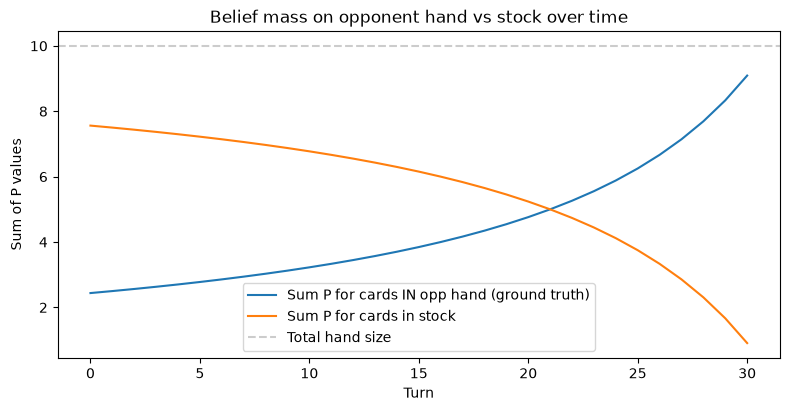

In [ ]:
random.seed(1)
deck2 = make_deck()
random.shuffle(deck2)

own2   = deck2[:10]
opp2   = deck2[10:20]
stock2 = deck2[21:]
fu2    = deck2[20]

bs4 = BeliefState(own2, fu2)

# current_opp_hand tracks the TRUE opponent hand as it evolves:
# each turn they draw a stock card (added) and discard one of their cards (removed).
# We need this because opp2 is fixed at the start — it includes cards already
# discarded, which have P=0 and would drag sums_in down if we kept using it.
current_opp_hand = list(opp2)

sums_in  = [sum(bs4.prob(c) for c in current_opp_hand)]
sums_out = [sum(bs4.prob(c) for c in stock2)]

stock_idx = 0
for turn in range(30):
    drawn     = stock2[stock_idx]; stock_idx += 1
    discarded = current_opp_hand[0]   # discard from front (simulates deadwood removal)

    bs4.observe_stock_draw_then_discard(discarded)

    # Update the true current hand
    current_opp_hand.remove(discarded)
    current_opp_hand.append(drawn)

    sums_in.append(sum(bs4.prob(c) for c in current_opp_hand))
    sums_out.append(sum(bs4.prob(c) for c in stock2[stock_idx:]))  # remaining stock only

turns = list(range(len(sums_in)))
plt.figure(figsize=(8, 4))
plt.plot(turns, sums_in,  label='Sum P for cards IN opp hand')
plt.plot(turns, sums_out, label='Sum P for cards in stock')
plt.axhline(10, color='grey', linestyle='--', alpha=0.4, label='Total hand size')
plt.xlabel('Turn'); plt.ylabel('Sum of P values'); plt.legend(); plt.tight_layout()
plt.title('Belief mass on opponent hand vs stock over time')
plt.show()

## Summary

This method relies strictly on directly observable actions—such as discards—to estimate the opponent's hand. While functional, the predictive accuracy could be significantly improved by implementing Bayesian updates. Incorporating probabilistic inference on both the opponent's discards and their choice of draws would allow the model to dynamically refine its beliefs based on strategic play rather than simple elimination.